# Kapitel 9 - Lösungen

In [1]:
# Aufgabe 1
from typing import Callable
type RealFun = Callable([float],float)
import math
def ableitung(f:RealFun,x:float,h=0.00001)->float:
    return (f(x+h)-f(x-h))/(2*h)
def zweiteAbleitung(f:RealFun,x:float,h=0.00001)->float:
    return (f(x+h)-2*f(x)+f(x-h))/h**2
print("sin''(0)=",zweiteAbleitung(math.sin,0))
def Newton(f:RealFun,x0:float,eps=1e-8)->float:
    while abs(f(x0))>eps:
        x0+=-f(x0)/ableitung(f,x0)
    return x0
Newton(lambda x0: zweiteAbleitung(lambda x: x*(x-1)**2,x0), 0.1)

sin''(0)= 0.0


0.6666666845158533

In [2]:
# Aufgabe 2
# Unsteigkeitsstellen könenn numerisch eigenlich nicht gefnden werden
# Ausweg. Stellen mit großen Veränderungen suchen
def unstetig(f,a,b,n=1000,M=50):
    dx=(b-a)/n
    stellen=[]
    for i in range(n):
        if abs(f(a+i*dx)-f(a+(i+1)*dx))>M*dx:
            stellen=stellen+[a+i*dx]
    return stellen            
def testfunkt(x):
    if x<=1:
        return x**2
    return 3-x
unstetig(testfunkt,-5,5)

[1.0]

In [3]:
# Aufgabe 3
def Bogenlänge(f,a,b,n=1000):
    s=0
    dx=(b-a)/n
    for k in range(n):
        x=a+k*dx
        s+=math.sqrt(dx**2+(f(x+dx)-f(x))**2)
    return s
print("1. Funktion: Bogenlänge des sin von 0..pi=",Bogenlänge(math.sin,0,math.pi))

def D(f:RealFun,h=0.000001)->RealFun:
    return lambda x: (f(x+h)-f(x-h))/(2*h)  
def Integral(f:RealFun,a,b,n=1000)->float:
    dx=(b-a)/n
    return sum([f(a+(i+0.5)*dx)*dx for i in range(n)])
def Bogenlänge2(f:RealFun,a:float,b:float)->float:
    return Integral(lambda x: math.sqrt(1+D(f)(x)**2), a,b)
print("2. Funktion: Bogenlänge des sin von 0..pi=",Bogenlänge2(math.sin,0,math.pi))

1. Funktion: Bogenlänge des sin von 0..pi= 3.8201972963123763
2. Funktion: Bogenlänge des sin von 0..pi= 3.820197789103384


In [4]:
# Aufgabe 4
def Krümmung(f:RealFun)->RealFun:
    return lambda x: D(D(f))(x)/(1+D(f)(x)**2)**1.5 
print("Krümmung Normalparabel am Scheitel=",Krümmung(lambda x: x**2)(0))
s=math.sin; 
Integral(lambda x: Krümmung(s)(x)*math.sqrt(1+D(s)(x)**2),0,math.pi)

Krümmung Normalparabel am Scheitel= 2.0


-1.570795103007755

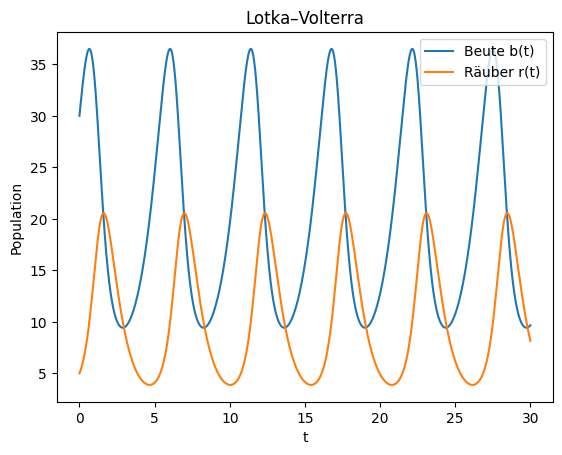

In [5]:
# Aufgabe 4
import numpy as np
import matplotlib.pyplot as plt
def RungeKuttaSys(g, x0, y0, xe, n=100):
    dx = (xe - x0) / n
    xs = [x0]
    ys = [np.array(y0, dtype=float)] 
    for i in range(1, n+1):
        y = ys[-1]
        x=x0+i*dx; xm=x+dx/2; x1=x+dx
        xs.append(x)
        k1 = g(x,y); k2 = g(xm, y + k1*dx/2)
        k3 = g(xm, y + k2*dx/2); k4 = g(x1, y + k3*dx)
        ys.append(y + dx/6*(k1 + 2*k2 + 2*k3 + k4))
    return [xs, ys]

# Parameter 
alpha = 1.0; beta  = 0.1
gamma = 1.5; delta = 0.075
def g_lv(t, y):
    b = y[0]   # Beute
    r = y[1]   # Räuber
    db = alpha*b - beta*b*r
    dr = delta*b*r - gamma*r
    return np.array([db, dr], dtype=float)
# Startwerte (nicht im Gleichgewicht)
b0 = 30.0; r0 = 5.0
t0 = 0.0; te = 30.0; n  = 3000  # viele Schritte für glatte Kurven
[ts, ys] = RungeKuttaSys(g_lv, t0, [b0, r0], te, n=n)
bs = np.array([v[0] for v in ys], dtype=float)
rs = np.array([v[1] for v in ys], dtype=float)
plt.figure()
plt.plot(ts, bs, label="Beute b(t)")
plt.plot(ts, rs, label="Räuber r(t)")
plt.xlabel("t"); plt.ylabel("Population")
plt.title("Lotka–Volterra")
plt.legend(); plt.show()